# Pilot Experiment — PPS Generation on 4 PPG Windows

Kiểm thử PPS Core v1 trên bốn cửa sổ PPG ghép cặp của Session 1. Notebook chỉ đánh giá lựa chọn rho, quá trình sinh PPS, bảo toàn waveform/geometry và temporal randomization.

In [1]:
# TASK 1 - Imports and global configuration
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.spatial import cKDTree


def find_project_root():
    """Locate the repository root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "phase1"))

from src.dataloader.loader import load_segmented_session
from src.surrogates.pps import (
    embed_phase_space,
    generate_pps_signal,
    optimize_rho,
    summarize_pps_indices,
)

SESSION = "sample_1.csv"
WINDOW_SIZE_S = 60
EMBEDDING_DIMENSION = 8
MASTER_SEED = 20_260_824
SEGMENT_LENGTH = 2
COUNT_MODE = "at_least"
TAU_SECONDS = {"Processed": 0.16, "Raw": 0.20}
COARSE_RHO = np.logspace(-2, 5, 29)
COARSE_TRIALS = 3
FINE_POINTS = 17
FINE_TRIALS = 5
N_SURROGATES = 10
DIAMETER_PAIRS = 200_000
CARDIAC_BAND_HZ = (0.5, 4.0)
STATE_NAMES = {0: "Awake", 1: "Drowsy"}
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

In [2]:
# TASK 2 - Load four matched pilot windows with the core loader
processed_data, processed_metadata = load_segmented_session(
    SESSION,
    window_sizes=WINDOW_SIZE_S,
    representation="processed",
    stationarity_only=True,
)
raw_data, raw_metadata = load_segmented_session(
    SESSION,
    window_sizes=WINDOW_SIZE_S,
    representation="raw",
    stationarity_only=False,
)
processed_batch = processed_data[WINDOW_SIZE_S]
raw_batch = raw_data[WINDOW_SIZE_S]

matched_window_ids = {}
for label, state in STATE_NAMES.items():
    eligible = np.flatnonzero(processed_batch["label"] == label)
    if not len(eligible):
        raise ValueError(f"Không có Processed {state} hợp lệ.")
    matched_window_ids[state] = int(
        processed_batch["window_id"][eligible[0]]
    )

pilot_windows = {}
for representation, batch in (
    ("Processed", processed_batch),
    ("Raw", raw_batch),
):
    for label, state in STATE_NAMES.items():
        window_id = matched_window_ids[state]
        matches = np.flatnonzero(batch["window_id"] == window_id)
        if len(matches) != 1:
            raise ValueError(f"Không ghép được window {window_id}.")
        index = int(matches[0])
        sampling_rate = float(batch["fs"])
        key = f"{representation} {state}"
        pilot_windows[key] = {
            "representation": representation,
            "state": state,
            "signal": batch["signal"][index].astype(float),
            "sampling_rate": sampling_rate,
            "tau_samples": int(
                round(TAU_SECONDS[representation] * sampling_rate)
            ),
            "window_id": window_id,
            "start_time": float(batch["start_time"][index]),
            "end_time": float(batch["end_time"][index]),
        }

selection_summary = pd.DataFrame(
    [
        {
            "representation": item["representation"],
            "state": item["state"],
            "window_id": item["window_id"],
            "start_time": item["start_time"],
            "end_time": item["end_time"],
            "stationarity_filter": (
                "ON"
                if item["representation"] == "Processed"
                else "OFF"
            ),
        }
        for item in pilot_windows.values()
    ]
)
selection_summary

,representation,state,window_id,start_time,end_time,stationarity_filter
0,Processed,Awake,1,2.63,62.61,ON
1,Processed,Drowsy,18,1117.37,1177.35,ON
2,Raw,Awake,1,2.63,62.61,OFF
3,Raw,Drowsy,18,1117.37,1177.35,OFF


In [3]:
# TASK 3 - Input validation summary
validation_rows = []
for key, item in pilot_windows.items():
    signal = item["signal"]
    sampling_rate = item["sampling_rate"]
    n_embedded = len(signal) - (
        EMBEDDING_DIMENSION - 1
    ) * item["tau_samples"]
    row = {
        "representation": item["representation"],
        "state": item["state"],
        "window_id": item["window_id"],
        "N": len(signal),
        "duration_s": len(signal) / sampling_rate,
        "sampling_rate": sampling_rate,
        "tau_samples": item["tau_samples"],
        "m": EMBEDDING_DIMENSION,
        "mean": signal.mean(),
        "std": signal.std(),
        "min": signal.min(),
        "max": signal.max(),
        "NaN_count": int(np.isnan(signal).sum()),
        "Inf_count": int(np.isinf(signal).sum()),
    }
    row["valid"] = bool(
        abs(row["duration_s"] - WINDOW_SIZE_S) <= 0.1
        and row["NaN_count"] == 0
        and row["Inf_count"] == 0
        and n_embedded >= 2
    )
    item["valid"] = row["valid"]
    validation_rows.append(row)

input_summary = pd.DataFrame(validation_rows)
display(input_summary)
invalid = input_summary.loc[~input_summary["valid"]]
if not invalid.empty:
    raise ValueError("Có pilot window không hợp lệ; dừng xử lý.")

,representation,state,window_id,N,duration_s,sampling_rate,tau_samples,m,mean,std,min,max,NaN_count,Inf_count,valid
0,Processed,Awake,1,3000,60.0,50.0,8,8,0.417650,199.137241,-397.348439,343.484725,0,0,True
1,Processed,Drowsy,18,3000,60.0,50.0,8,8,0.565305,158.975628,-385.830449,292.135417,0,0,True
2,Raw,Awake,1,3000,60.0,50.0,10,8,92497.936667,1871.765655,90162.000000,97507.000000,0,0,True
3,Raw,Drowsy,18,3000,60.0,50.0,10,8,92342.797000,448.906566,91405.000000,93542.000000,0,0,True


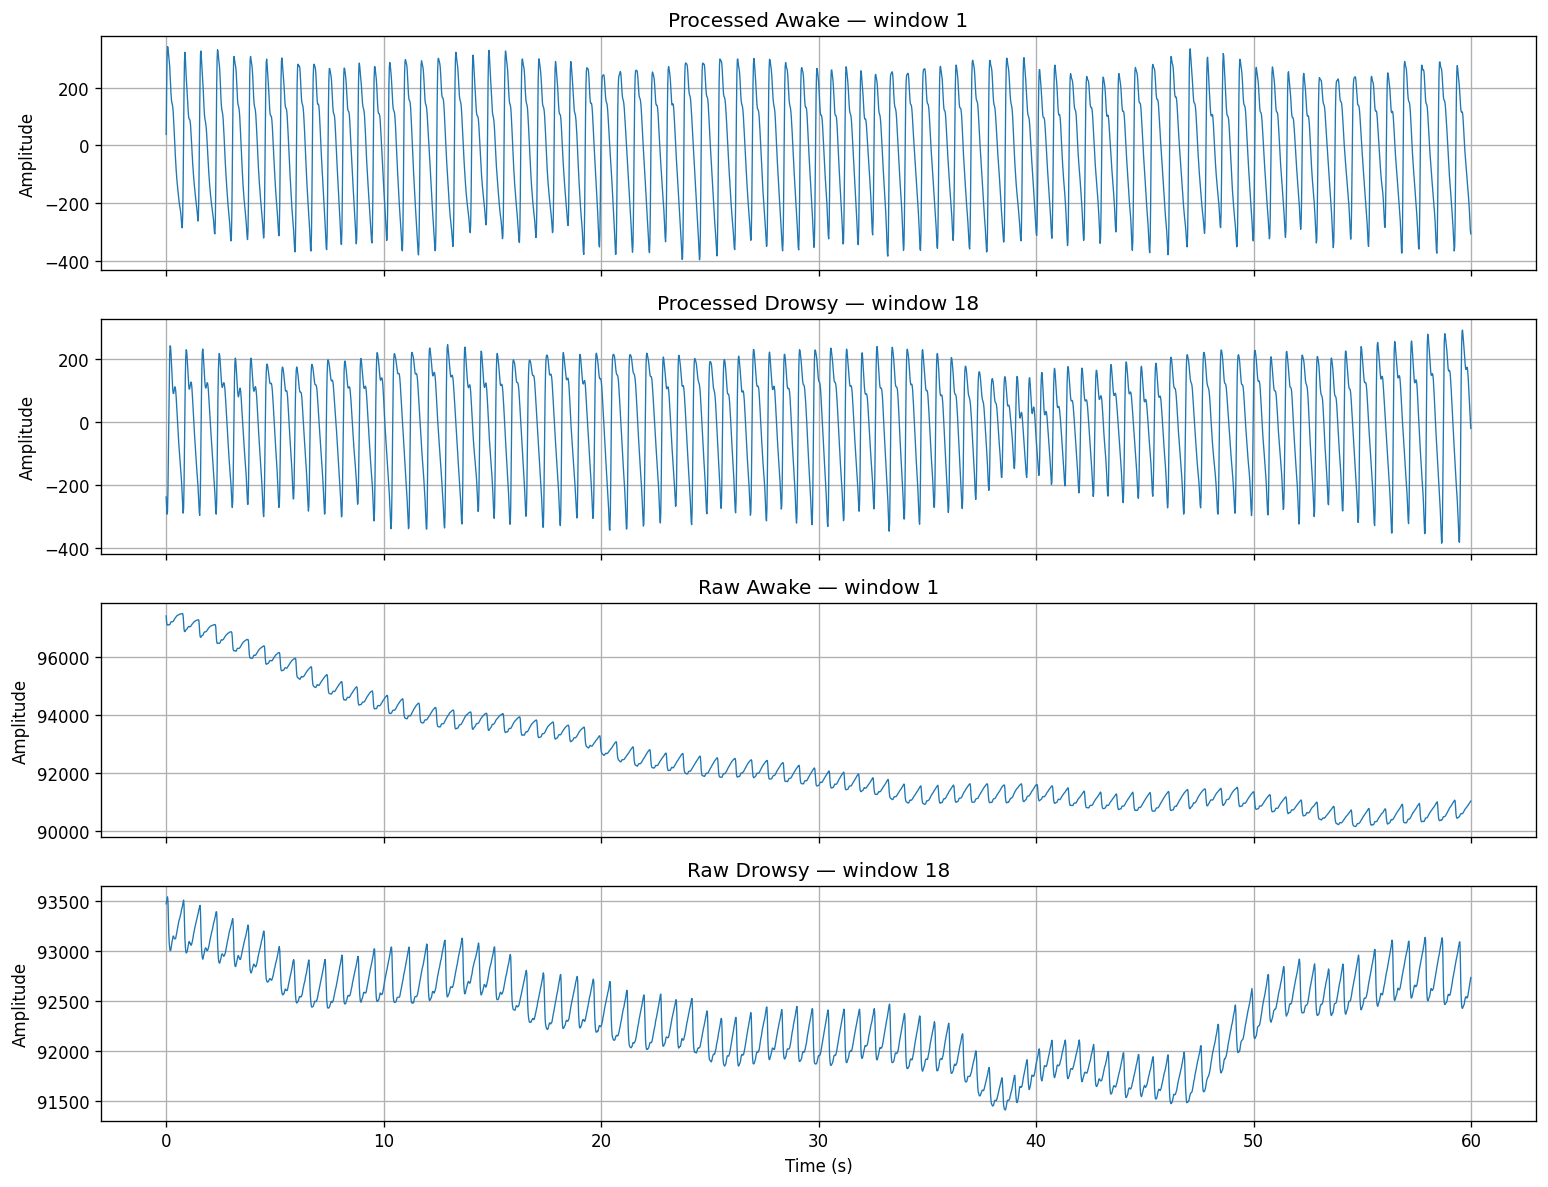

In [4]:
# TASK 4 - Visualize original PPG windows
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for axis, (key, item) in zip(axes, pilot_windows.items()):
    time = np.arange(len(item["signal"])) / item["sampling_rate"]
    axis.plot(time, item["signal"], linewidth=0.8)
    axis.set_title(f"{key} — window {item['window_id']}")
    axis.set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

In [5]:
# TASK 5 - Phase-space reconstruction and distance scale
distance_rows = []
diameter_seeds = np.random.SeedSequence(MASTER_SEED).spawn(4)
for seed, (key, item) in zip(diameter_seeds, pilot_windows.items()):
    embedded = embed_phase_space(
        item["signal"],
        item["tau_samples"],
        EMBEDDING_DIMENSION,
    )
    item["embedded"] = embedded
    nearest = cKDTree(embedded).query(embedded, k=2)[0][:, 1]
    rng = np.random.default_rng(seed)
    pairs = rng.integers(
        0, len(embedded), size=(DIAMETER_PAIRS, 2)
    )
    pair_distances = np.linalg.norm(
        embedded[pairs[:, 0]] - embedded[pairs[:, 1]],
        axis=1,
    )
    item["nn_median"] = float(np.median(nearest))
    item["approx_diameter"] = float(pair_distances.max())
    distance_rows.append(
        {
            "representation": item["representation"],
            "state": item["state"],
            "Z_shape": embedded.shape,
            "signal_std": item["signal"].std(),
            "signal_range": np.ptp(item["signal"]),
            "nn_q05": np.quantile(nearest, 0.05),
            "nn_median": item["nn_median"],
            "nn_q95": np.quantile(nearest, 0.95),
            "approx_diameter": item["approx_diameter"],
        }
    )

distance_summary = pd.DataFrame(distance_rows)
distance_summary

,representation,state,Z_shape,signal_std,signal_range,nn_q05,nn_median,nn_q95,approx_diameter
0,Processed,Awake,"(2944, 8)",199.137241,740.833164,25.951010,42.197122,68.831068,1269.607100
1,Processed,Drowsy,"(2944, 8)",158.975628,677.965866,20.510461,36.812440,59.309004,1213.223095
2,Raw,Awake,"(2930, 8)",1871.765655,7345.000000,40.112342,75.901228,216.348091,19322.543388
3,Raw,Drowsy,"(2930, 8)",448.906566,2137.000000,43.646306,67.790115,144.072030,4828.847482


In [6]:
# TASK 6 - Coarse rho sweep
coarse_seeds = np.random.SeedSequence(MASTER_SEED + 1).spawn(4)
for seed, item in zip(coarse_seeds, pilot_windows.values()):
    result = optimize_rho(
        signal=item["signal"],
        tau=item["tau_samples"],
        m=EMBEDDING_DIMENSION,
        rho_candidates=COARSE_RHO,
        trials=COARSE_TRIALS,
        segment_length=SEGMENT_LENGTH,
        count_mode=COUNT_MODE,
        seed=int(seed.generate_state(1)[0]),
    )
    item["coarse_result"] = result
    item["coarse_rho_star"] = result["optimal_rho"]

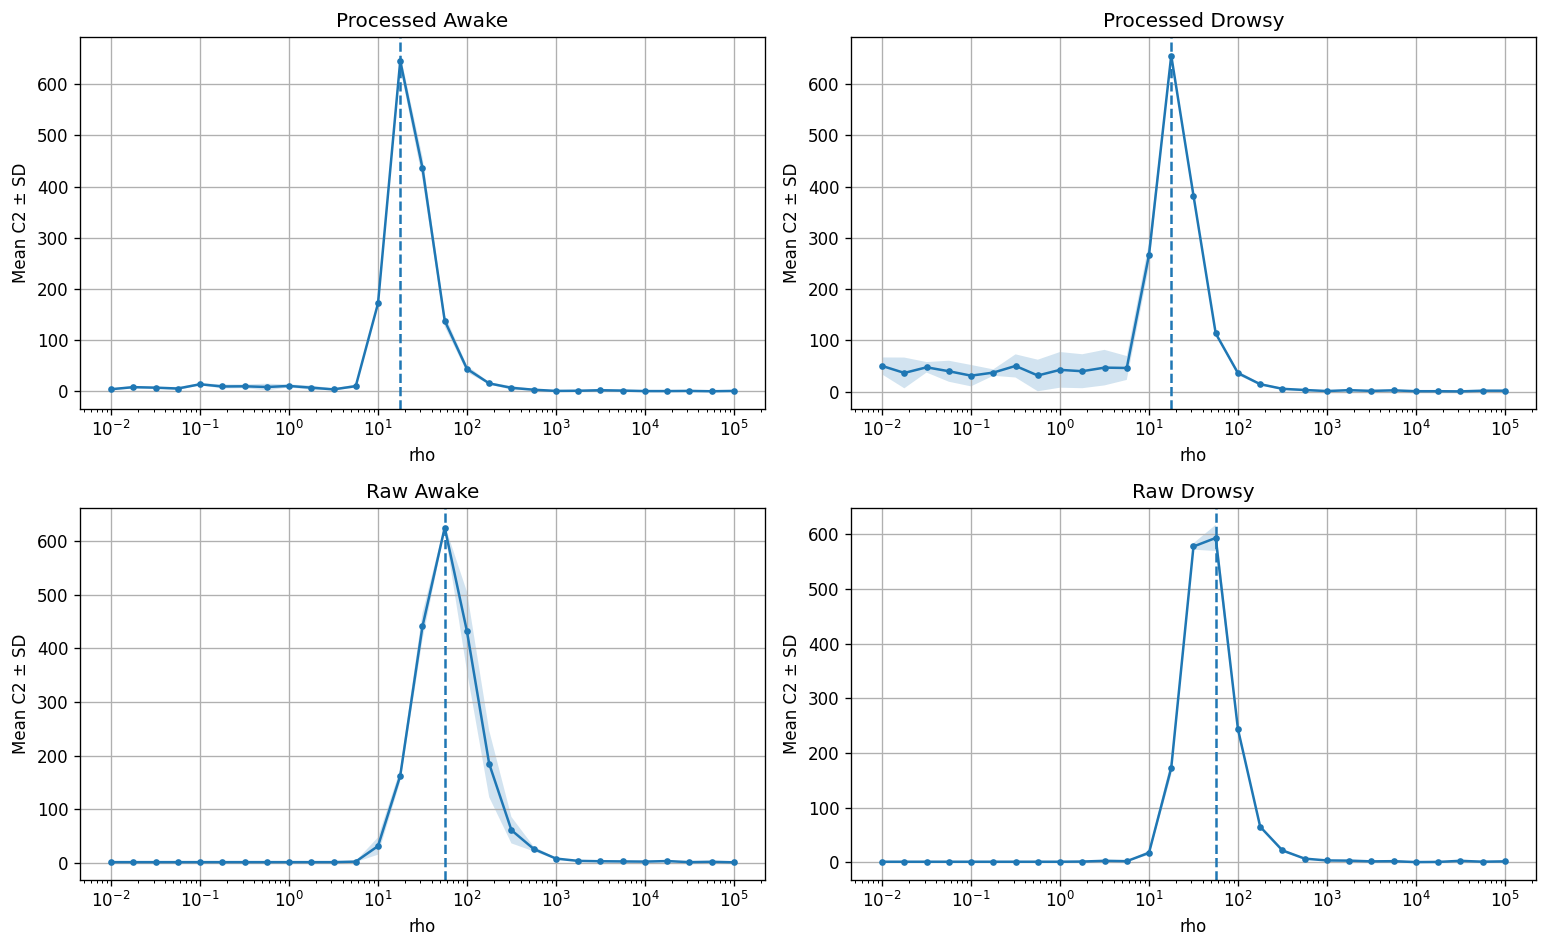

,representation,state,coarse_rho_star,interior_peak,peak_edge_ratio,pass
0,Processed,Awake,17.782794,True,148.923077,True
1,Processed,Drowsy,17.782794,True,13.113333,True
2,Raw,Awake,56.234133,True,625.333333,True
3,Raw,Drowsy,56.234133,True,356.000000,True


In [7]:
# TASK 7 - Plot and validate coarse C2(rho)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
coarse_rows = []
for axis, (key, item) in zip(axes.flat, pilot_windows.items()):
    result = item["coarse_result"]
    rho = result["rho_candidates"]
    mean = result["mean_counts"]
    std = result["std_counts"]
    best_index = int(np.argmax(mean))
    interior = best_index not in {0, len(rho) - 1}
    edge_level = max(float(mean[0]), float(mean[-1]), 1.0)
    peak_edge_ratio = float(mean[best_index] / edge_level)
    identifiable = peak_edge_ratio >= 2.0
    item["coarse_interior"] = interior
    item["coarse_peak_identifiable"] = identifiable
    item["coarse_peak_edge_ratio"] = peak_edge_ratio
    axis.plot(rho, mean, marker="o", markersize=3)
    axis.fill_between(rho, mean - std, mean + std, alpha=0.2)
    axis.axvline(item["coarse_rho_star"], linestyle="--")
    axis.set_xscale("log")
    axis.set_title(key)
    axis.set_xlabel("rho")
    axis.set_ylabel("Mean C2 ± SD")
    coarse_rows.append(
        {
            "representation": item["representation"],
            "state": item["state"],
            "coarse_rho_star": item["coarse_rho_star"],
            "interior_peak": interior,
            "peak_edge_ratio": peak_edge_ratio,
            "pass": interior and identifiable,
        }
    )
fig.tight_layout()
plt.show()
coarse_summary = pd.DataFrame(coarse_rows)
display(coarse_summary)
if not coarse_summary["pass"].all():
    raise RuntimeError("Coarse grid chưa tạo interior peak rõ.")

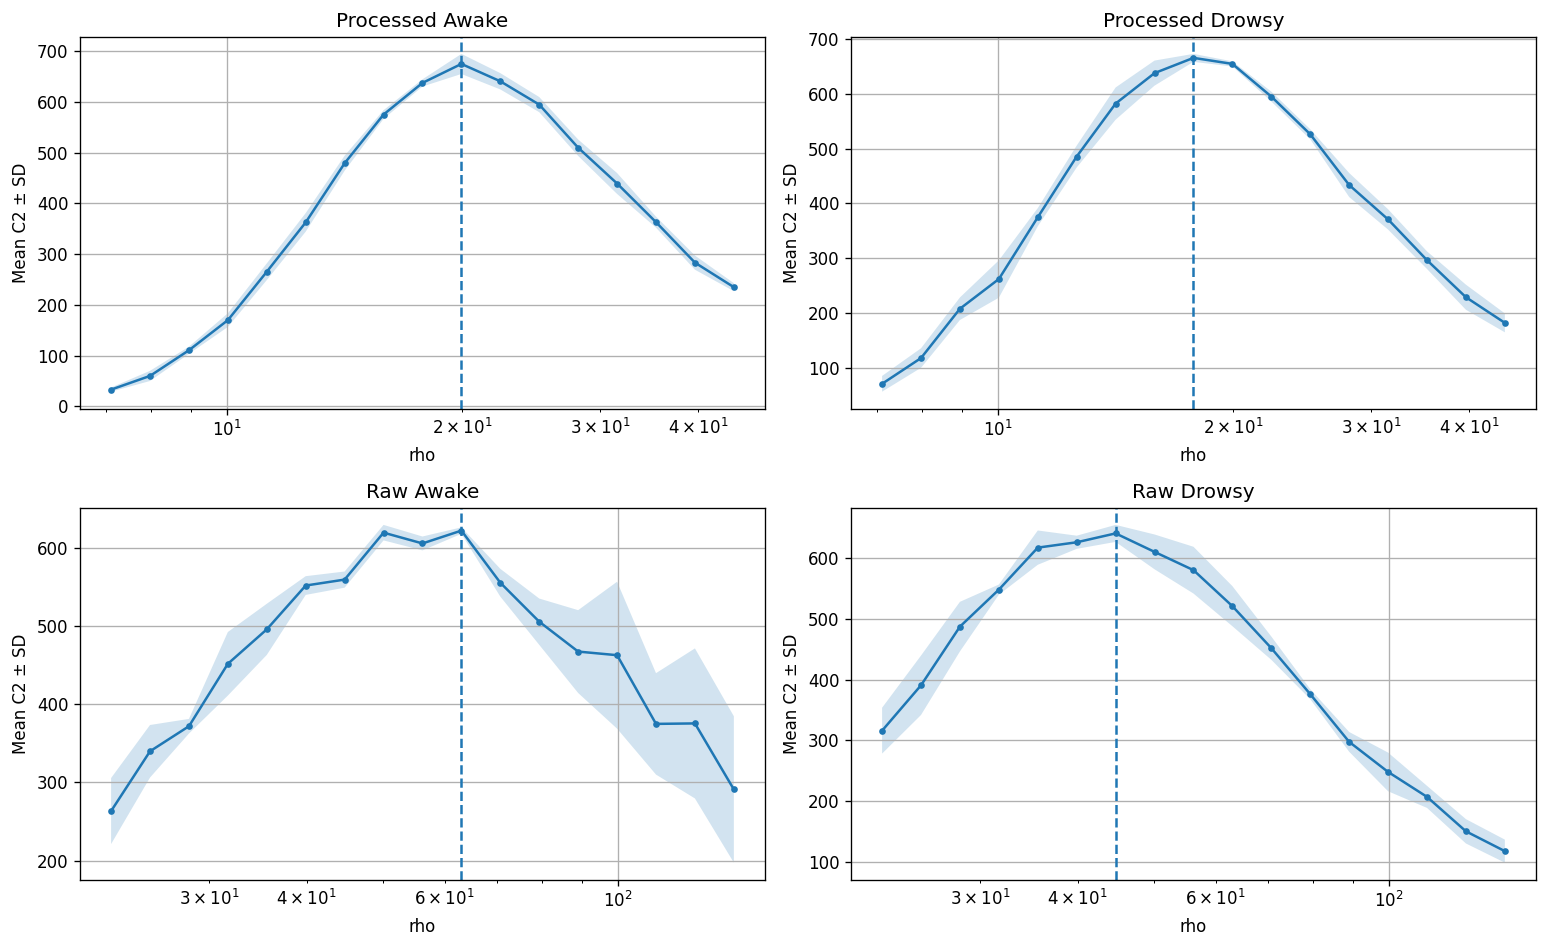

,representation,state,coarse_rho_star,fine_rho_star,peak_C2,peak_width_ratio,fine_interior
0,Processed,Awake,17.782794,19.940796,675.0,1.000000,True
1,Processed,Drowsy,17.782794,17.782794,665.4,1.257433,True
2,Raw,Awake,56.234133,63.058335,621.8,1.257433,True
3,Raw,Drowsy,56.234133,44.721360,640.2,1.410027,True


In [8]:
# TASK 8 - Fine rho sweep and peak width
fine_seeds = np.random.SeedSequence(MASTER_SEED + 2).spawn(4)
fine_rows = []
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for axis, seed, (key, item) in zip(
    axes.flat, fine_seeds, pilot_windows.items()
):
    coarse_rho = item["coarse_rho_star"]
    fine_rho = np.geomspace(
        coarse_rho / 2.5, coarse_rho * 2.5, FINE_POINTS
    )
    result = optimize_rho(
        signal=item["signal"],
        tau=item["tau_samples"],
        m=EMBEDDING_DIMENSION,
        rho_candidates=fine_rho,
        trials=FINE_TRIALS,
        segment_length=SEGMENT_LENGTH,
        count_mode=COUNT_MODE,
        seed=int(seed.generate_state(1)[0]),
    )
    mean = result["mean_counts"]
    std = result["std_counts"]
    best_index = int(np.argmax(mean))
    high = fine_rho[mean >= 0.95 * mean[best_index]]
    item["fine_result"] = result
    item["rho_star"] = result["optimal_rho"]
    item["c2_peak"] = float(mean[best_index])
    item["peak_width_ratio"] = float(high[-1] / high[0])
    item["fine_interior"] = best_index not in {
        0, len(fine_rho) - 1
    }
    axis.plot(fine_rho, mean, marker="o", markersize=3)
    axis.fill_between(fine_rho, mean - std, mean + std, alpha=0.2)
    axis.axvline(item["rho_star"], linestyle="--")
    axis.set_xscale("log")
    axis.set_title(key)
    axis.set_xlabel("rho")
    axis.set_ylabel("Mean C2 ± SD")
    fine_rows.append(
        {
            "representation": item["representation"],
            "state": item["state"],
            "coarse_rho_star": coarse_rho,
            "fine_rho_star": item["rho_star"],
            "peak_C2": item["c2_peak"],
            "peak_width_ratio": item["peak_width_ratio"],
            "fine_interior": item["fine_interior"],
        }
    )
fig.tight_layout()
plt.show()
fine_summary = pd.DataFrame(fine_rows)
display(fine_summary)
if not fine_summary["fine_interior"].all():
    raise RuntimeError("Fine rho optimum nằm ở grid boundary.")

In [9]:
# TASK 9 - Relative rho scale
relative_rows = []
for item in pilot_windows.values():
    item["rho_over_diameter"] = (
        item["rho_star"] / item["approx_diameter"]
    )
    item["rho_over_nn"] = (
        item["rho_star"] / item["nn_median"]
    )
    relative_rows.append(
        {
            "representation": item["representation"],
            "state": item["state"],
            "rho_star": item["rho_star"],
            "rho_over_diameter": item["rho_over_diameter"],
            "rho_over_median_nn": item["rho_over_nn"],
        }
    )
relative_rho_summary = pd.DataFrame(relative_rows)
relative_rho_summary

,representation,state,rho_star,rho_over_diameter,rho_over_median_nn
0,Processed,Awake,19.940796,0.015706,0.472563
1,Processed,Drowsy,17.782794,0.014657,0.483065
2,Raw,Awake,63.058335,0.003263,0.830795
3,Raw,Drowsy,44.721360,0.009261,0.659703


In [10]:
# TASK 10 - Generate a deterministic 40-member PPS ensemble
surrogate_seeds = np.random.SeedSequence(MASTER_SEED + 3).spawn(
    len(pilot_windows) * N_SURROGATES
)
seed_iterator = iter(surrogate_seeds)
for item in pilot_windows.values():
    item["surrogates"] = []
    for surrogate_id in range(1, N_SURROGATES + 1):
        seed = next(seed_iterator)
        signal, indices = generate_pps_signal(
            signal=item["signal"],
            tau=item["tau_samples"],
            m=EMBEDDING_DIMENSION,
            rho=item["rho_star"],
            rng=np.random.default_rng(seed),
            return_indices=True,
        )
        item["surrogates"].append(
            {
                "surrogate_id": surrogate_id,
                "signal": signal,
                "indices": indices,
            }
        )

ensemble_summary = pd.DataFrame(
    [
        {
            "representation": item["representation"],
            "state": item["state"],
            "rho_star": item["rho_star"],
            "n_surrogates": len(item["surrogates"]),
            "surrogate_length": len(
                item["surrogates"][0]["signal"]
            ),
        }
        for item in pilot_windows.values()
    ]
)
ensemble_summary

,representation,state,rho_star,n_surrogates,surrogate_length
0,Processed,Awake,19.940796,10,3000
1,Processed,Drowsy,17.782794,10,3000
2,Raw,Awake,63.058335,10,3000
3,Raw,Drowsy,44.721360,10,3000


In [11]:
# TASK 11 - Copied-run diagnostics
run_rows = []
for item in pilot_windows.values():
    for surrogate in item["surrogates"]:
        summary = summarize_pps_indices(surrogate["indices"])
        run_rows.append(
            {
                "representation": item["representation"],
                "state": item["state"],
                "surrogate_id": surrogate["surrogate_id"],
                "run_count": summary["run_count"],
                "mean_run_length": summary["mean_run_length"],
                "max_run_length": summary["max_run_length"],
                "successor_fraction": (
                    summary["successor_fraction"]
                ),
            }
        )
run_diagnostics = pd.DataFrame(run_rows)
run_aggregate = run_diagnostics.groupby(
    ["representation", "state"]
)[[
    "run_count",
    "mean_run_length",
    "max_run_length",
    "successor_fraction",
]].agg(["mean", "median", "min", "max"])
display(run_diagnostics)
run_aggregate

,representation,state,surrogate_id,run_count,mean_run_length,max_run_length,successor_fraction
0,Processed,Awake,1,1473,2.036660,13,0.509170
1,Processed,Awake,2,1505,1.993355,15,0.498499
2,Processed,Awake,3,1443,2.079002,16,0.519173
3,Processed,Awake,4,1437,2.087683,17,0.521174
4,Processed,Awake,5,1500,2.000000,15,0.500167
5,Processed,Awake,6,1539,1.949318,17,0.487162
6,Processed,Awake,7,1497,2.004008,15,0.501167
7,Processed,Awake,8,1473,2.036660,22,0.509170
8,Processed,Awake,9,1479,2.028398,11,0.507169
9,Processed,Awake,10,1472,2.038043,17,0.509503


run_count                     mean_run_length            \
                           mean  median   min   max            mean    median   
representation state                                                            
Processed      Awake     1481.8  1476.0  1437  1539        2.025313  2.032529   
               Drowsy    1502.2  1506.5  1392  1568        1.999860  1.991381   
Raw            Awake     1837.5  1846.5  1640  1979        1.637538  1.624937   
               Drowsy    1607.5  1613.0  1487  1708        1.869911  1.859923   

                                          max_run_length                 \
                            min       max           mean median min max   
representation state                                                      
Processed      Awake   1.949318  2.087683           15.8   15.5  11  22   
               Drowsy  1.913265  2.155172           18.6   17.0  14  26   
Raw            Awake   1.515917  1.829268           13.6   12.5  10  22   
               Drowsy  1.756440  2.017485           18.2   18.0  11  24   

                      successor_fraction                                
                                    mean    median       min       max  
representation state                                                    
Processed      Awake            0.506235  0.508169  0.487162  0.521174  
               Drowsy           0.499433  0.497999  0.477492  0.536179  
Raw            Awake            0.387629  0.384628  0.340447  0.453484  
               Drowsy           0.464321  0.462487  0.430810  0.504502

In [12]:
# TASK 12 - Waveform preservation metrics
def dominant_frequency(signal, sampling_rate):
    """Return the strongest frequency in the cardiac band."""
    centered = signal - signal.mean()
    power = np.abs(np.fft.rfft(centered)) ** 2
    frequencies = np.fft.rfftfreq(len(signal), d=1 / sampling_rate)
    in_band = (
        (frequencies >= CARDIAC_BAND_HZ[0])
        & (frequencies <= CARDIAC_BAND_HZ[1])
    )
    band_indices = np.flatnonzero(in_band)
    return float(band_indices[np.argmax(power[in_band])]) * (
        sampling_rate / len(signal)
    )


waveform_rows = []
for item in pilot_windows.values():
    original = item["signal"]
    original_frequency = dominant_frequency(
        original, item["sampling_rate"]
    )
    for surrogate in item["surrogates"]:
        signal = surrogate["signal"]
        surrogate_frequency = dominant_frequency(
            signal, item["sampling_rate"]
        )
        waveform_rows.append(
            {
                "representation": item["representation"],
                "state": item["state"],
                "surrogate_id": surrogate["surrogate_id"],
                "mean_difference": signal.mean() - original.mean(),
                "std_ratio": signal.std() / original.std(),
                "variance_ratio": (
                    signal.var() / original.var()
                ),
                "range_ratio": np.ptp(signal) / np.ptp(original),
                "dominant_frequency_original": original_frequency,
                "dominant_frequency_pps": surrogate_frequency,
                "dominant_frequency_abs_difference": abs(
                    surrogate_frequency - original_frequency
                ),
            }
        )
waveform_metrics = pd.DataFrame(waveform_rows)
waveform_aggregate = waveform_metrics.groupby(
    ["representation", "state"]
)[[
    "mean_difference",
    "std_ratio",
    "variance_ratio",
    "range_ratio",
    "dominant_frequency_abs_difference",
]].agg(["mean", "median", "min", "max"])
display(waveform_metrics)
waveform_aggregate

,representation,state,surrogate_id,mean_difference,std_ratio,variance_ratio,range_ratio,dominant_frequency_original,dominant_frequency_pps,dominant_frequency_abs_difference
0,Processed,Awake,1,-4.217480,0.997614,0.995235,0.983380,1.300000,1.300000,0.000000
1,Processed,Awake,2,2.763409,0.985945,0.972087,0.968202,1.300000,1.366667,0.066667
2,Processed,Awake,3,-4.305434,0.996980,0.993968,0.989810,1.300000,1.333333,0.033333
3,Processed,Awake,4,2.262003,0.979953,0.960308,0.968202,1.300000,1.366667,0.066667
4,Processed,Awake,5,-2.763982,1.004378,1.008775,0.987642,1.300000,1.316667,0.016667
5,Processed,Awake,6,-4.058498,1.009774,1.019643,0.983380,1.300000,1.300000,0.000000
6,Processed,Awake,7,-2.014373,1.003180,1.006370,0.989810,1.300000,1.333333,0.033333
7,Processed,Awake,8,-1.713236,1.012601,1.025361,1.000000,1.300000,1.300000,0.000000
8,Processed,Awake,9,5.796625,0.992754,0.985561,0.985548,1.300000,1.350000,0.050000
9,Processed,Awake,10,-0.250990,1.017351,1.035002,0.994581,1.300000,1.316667,0.016667


mean_difference                                        \
                                 mean       median          min         max   
representation state                                                          
Processed      Awake        -0.850195    -1.863804    -4.305434    5.796625   
               Drowsy       -1.835397    -2.038236    -4.615522    2.342588   
Raw            Awake     -1208.490033 -1316.845167 -1530.207000 -673.823667   
               Drowsy      -50.480467   -54.833000  -388.192667  388.742000   

                      std_ratio                               variance_ratio  \
                           mean    median       min       max           mean   
representation state                                                           
Processed      Awake   1.000053  1.000397  0.979953  1.017351       1.000231   
               Drowsy  0.996846  1.000956  0.970528  1.014867       0.993882   
Raw            Awake   0.295722  0.234686  0.141395  0.495566       0.108623   
               Drowsy  0.699320  0.719366  0.502562  0.984653       0.511379   

                                                    range_ratio            \
                         median       min       max        mean    median   
representation state                                                        
Processed      Awake   1.000802  0.960308  1.035002    0.985055  0.986595   
               Drowsy  1.001913  0.941924  1.029954    0.939615  0.936469   
Raw            Awake   0.057140  0.019992  0.245586    0.351327  0.279986   
               Drowsy  0.517701  0.252568  0.969542    0.730884  0.748245   

                                          dominant_frequency_abs_difference  \
                            min       max                              mean   
representation state                                                          
Processed      Awake   0.968202  1.000000                          0.028333   
               Drowsy  0.901264  0.983082                          0.031667   
Raw            Awake   0.220967  0.557250                          0.168333   
               Drowsy  0.592419  0.839027                          0.085000   

                                                     
                         median       min       max  
representation state                                 
Processed      Awake   0.025000  0.000000  0.066667  
               Drowsy  0.033333  0.000000  0.066667  
Raw            Awake   0.116667  0.000000  0.616667  
               Drowsy  0.066667  0.016667  0.216667

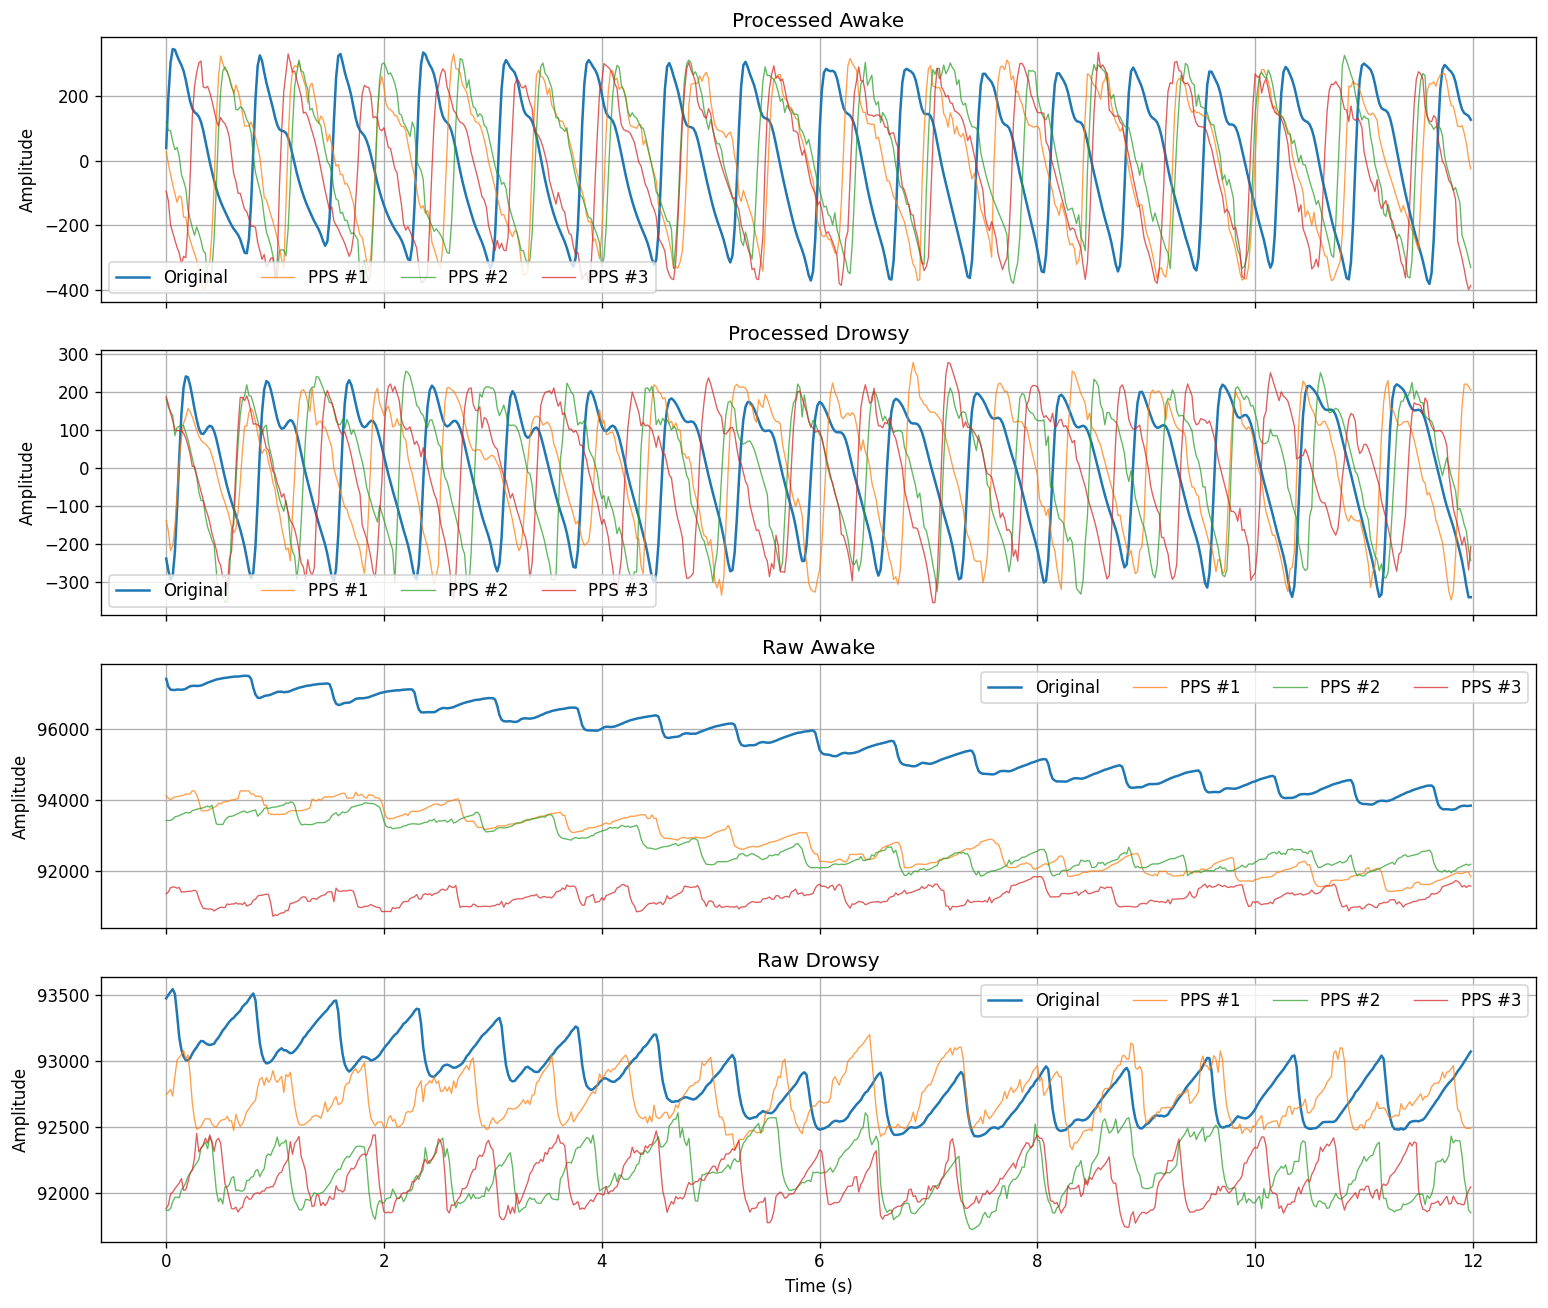

In [13]:
# TASK 13 - Original versus three representative PPS waveforms
display_seconds = 12.0
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for axis, (key, item) in zip(axes, pilot_windows.items()):
    n_display = int(display_seconds * item["sampling_rate"])
    time = np.arange(n_display) / item["sampling_rate"]
    axis.plot(
        time,
        item["signal"][:n_display],
        linewidth=1.5,
        label="Original",
    )
    for surrogate in item["surrogates"][:3]:
        axis.plot(
            time,
            surrogate["signal"][:n_display],
            linewidth=0.8,
            alpha=0.75,
            label=f"PPS #{surrogate['surrogate_id']}",
        )
    axis.set_title(key)
    axis.set_ylabel("Amplitude")
    axis.legend(ncol=4)
axes[-1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

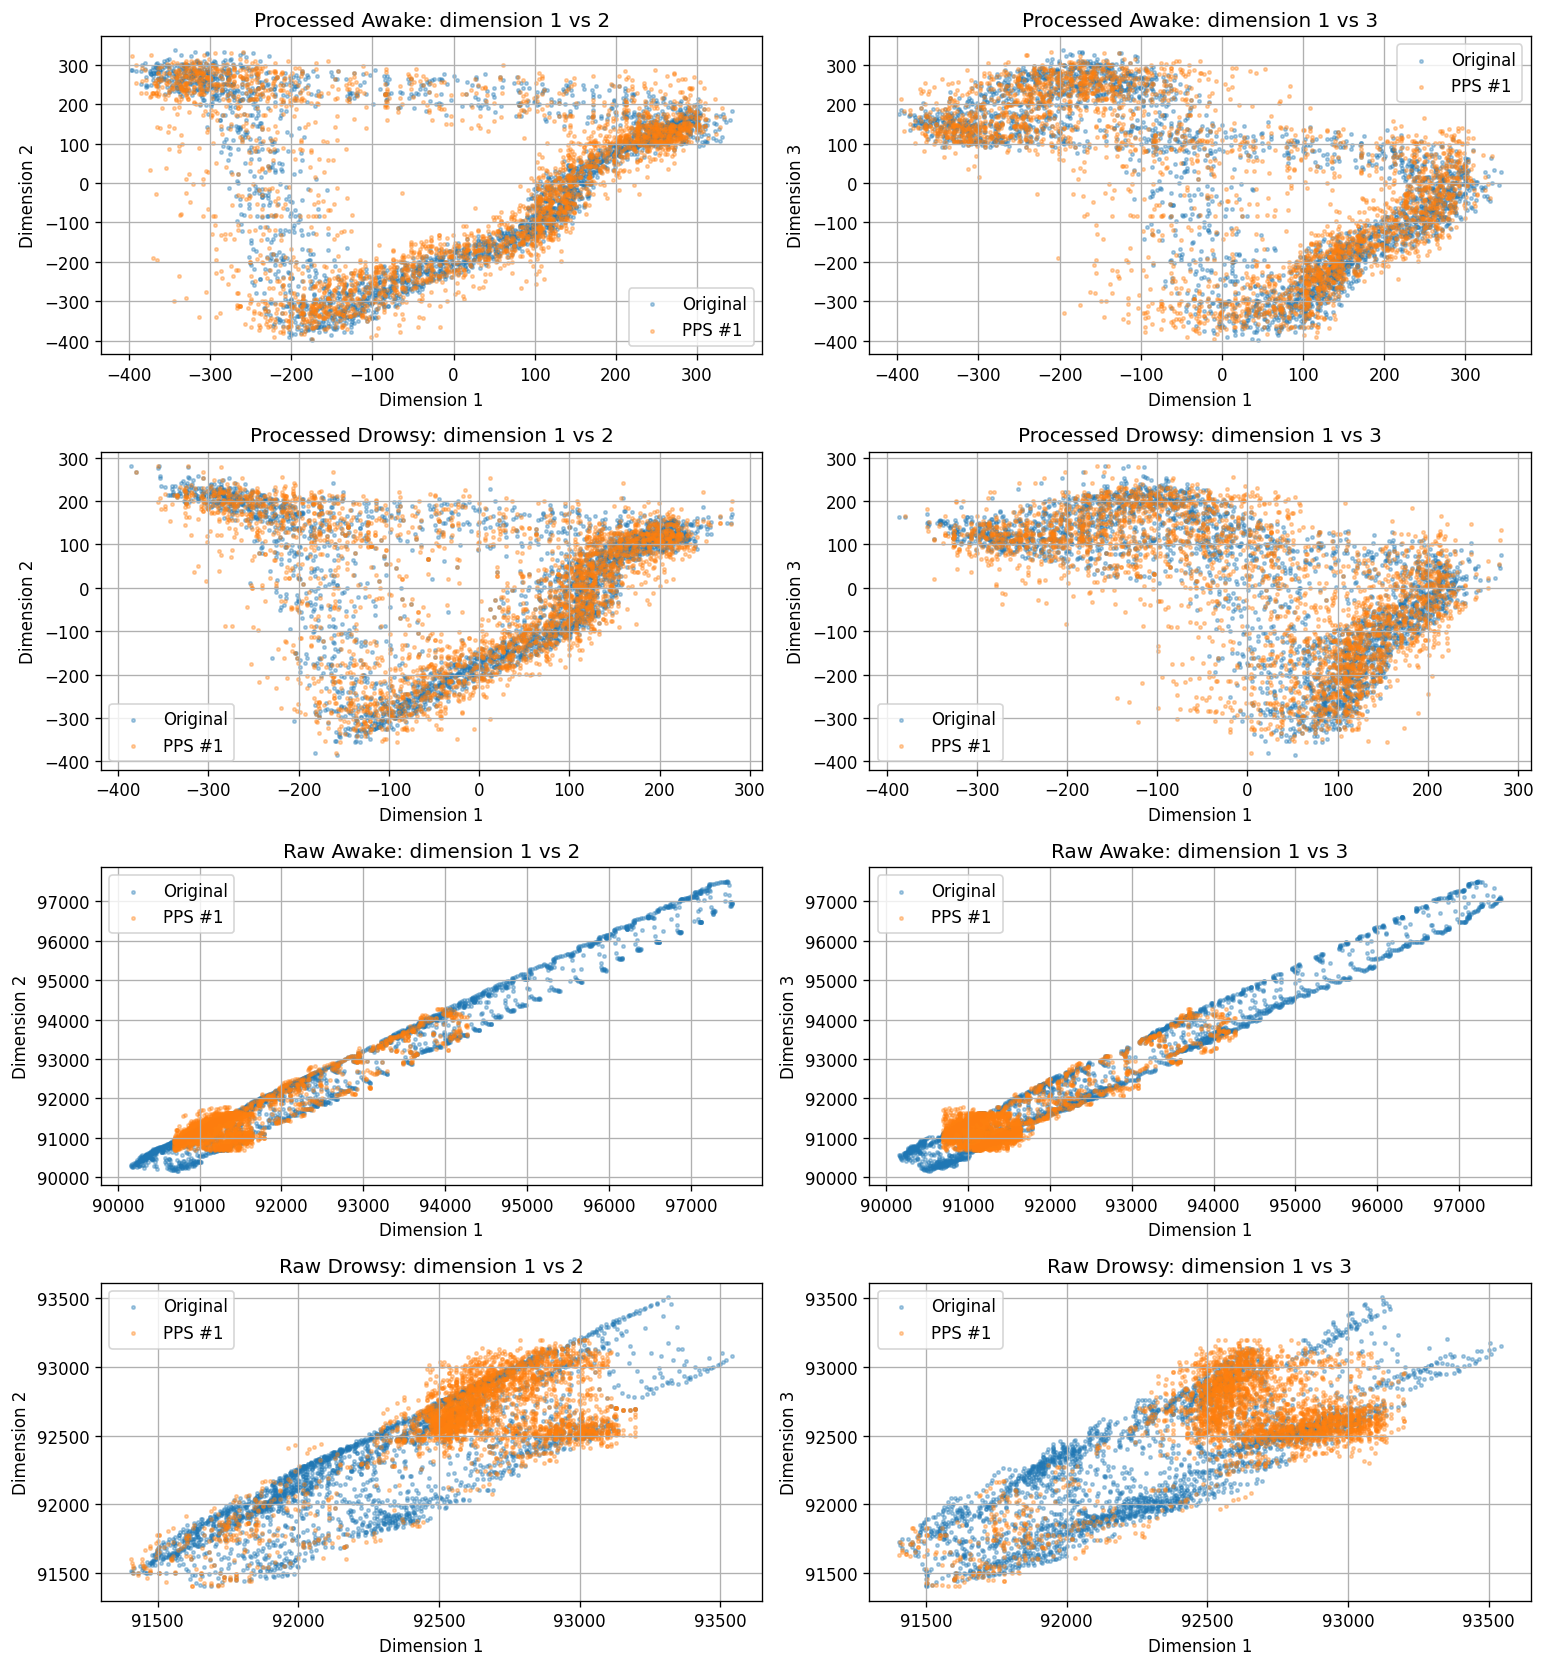

,representation,state,geometry_error_mean,geometry_error_median,geometry_error_min,geometry_error_max
0,Processed,Awake,0.065628,0.065910,0.061962,0.069133
1,Processed,Drowsy,0.065335,0.064608,0.062148,0.070692
2,Raw,Awake,0.017510,0.017620,0.015549,0.019779
3,Raw,Drowsy,0.045452,0.046009,0.038326,0.051197


In [14]:
# TASK 14 - Reconstructed scalar PPS geometry
fig, axes = plt.subplots(4, 2, figsize=(13, 14))
geometry_rows = []
for row, (key, item) in enumerate(pilot_windows.items()):
    original_z = item["embedded"]
    original_tree = cKDTree(original_z)
    geometry_errors = []
    surrogate_z = None
    for surrogate in item["surrogates"]:
        current_z = embed_phase_space(
            surrogate["signal"],
            item["tau_samples"],
            EMBEDDING_DIMENSION,
        )
        nearest = original_tree.query(current_z, k=1)[0]
        geometry_errors.append(
            np.median(nearest) / item["approx_diameter"]
        )
        if surrogate_z is None:
            surrogate_z = current_z
    geometry_errors = np.asarray(geometry_errors)
    item["geometry_error"] = float(geometry_errors.mean())
    geometry_rows.append(
        {
            "representation": item["representation"],
            "state": item["state"],
            "geometry_error_mean": geometry_errors.mean(),
            "geometry_error_median": np.median(geometry_errors),
            "geometry_error_min": geometry_errors.min(),
            "geometry_error_max": geometry_errors.max(),
        }
    )
    step = max(1, len(original_z) // 1_500)
    for column, dimension in enumerate((1, 2)):
        axis = axes[row, column]
        axis.scatter(
            original_z[::step, 0],
            original_z[::step, dimension],
            s=4,
            alpha=0.35,
            label="Original",
        )
        axis.scatter(
            surrogate_z[::step, 0],
            surrogate_z[::step, dimension],
            s=4,
            alpha=0.35,
            label="PPS #1",
        )
        axis.set_title(f"{key}: dimension 1 vs {dimension + 1}")
        axis.set_xlabel("Dimension 1")
        axis.set_ylabel(f"Dimension {dimension + 1}")
        axis.legend()
fig.tight_layout()
plt.show()
geometry_summary = pd.DataFrame(geometry_rows)
geometry_summary

In [15]:
# TASK 15 - Awake versus Drowsy rho comparison
state_comparison = fine_summary.merge(
    relative_rho_summary,
    on=["representation", "state"],
)[[
    "representation",
    "state",
    "fine_rho_star",
    "rho_over_diameter",
    "rho_over_median_nn",
    "peak_C2",
    "peak_width_ratio",
]].sort_values(["representation", "state"])
state_comparison

,representation,state,fine_rho_star,rho_over_diameter,rho_over_median_nn,peak_C2,peak_width_ratio
0,Processed,Awake,19.940796,0.015706,0.472563,675.0,1.000000
1,Processed,Drowsy,17.782794,0.014657,0.483065,665.4,1.257433
2,Raw,Awake,63.058335,0.003263,0.830795,621.8,1.257433
3,Raw,Drowsy,44.721360,0.009261,0.659703,640.2,1.410027


In [16]:
# TASK 16 - Raw versus Processed comparison
comparison_rows = []
for item in pilot_windows.values():
    selector = (
        (run_diagnostics["representation"] == item["representation"])
        & (run_diagnostics["state"] == item["state"])
    )
    runs = run_diagnostics.loc[selector]
    waveform_selector = (
        (waveform_metrics["representation"] == item["representation"])
        & (waveform_metrics["state"] == item["state"])
    )
    waveform = waveform_metrics.loc[waveform_selector]
    comparison_rows.append(
        {
            "representation": item["representation"],
            "state": item["state"],
            "rho_star": item["rho_star"],
            "rho_over_diameter": item["rho_over_diameter"],
            "rho_over_median_nn": item["rho_over_nn"],
            "C2_peak": item["c2_peak"],
            "mean_run_length": runs["mean_run_length"].mean(),
            "max_run_length": runs["max_run_length"].max(),
            "successor_fraction": (
                runs["successor_fraction"].mean()
            ),
            "variance_ratio": waveform["variance_ratio"].mean(),
            "range_ratio": waveform["range_ratio"].mean(),
            "geometry_error": item["geometry_error"],
        }
    )
raw_processed_summary = pd.DataFrame(comparison_rows)
raw_processed_summary

,representation,state,rho_star,rho_over_diameter,rho_over_median_nn,C2_peak,mean_run_length,max_run_length,successor_fraction,variance_ratio,range_ratio,geometry_error
0,Processed,Awake,19.940796,0.015706,0.472563,675.0,2.025313,22,0.506235,1.000231,0.985055,0.065628
1,Processed,Drowsy,17.782794,0.014657,0.483065,665.4,1.999860,26,0.499433,0.993882,0.939615,0.065335
2,Raw,Awake,63.058335,0.003263,0.830795,621.8,1.637538,22,0.387629,0.108623,0.351327,0.017510
3,Raw,Drowsy,44.721360,0.009261,0.659703,640.2,1.869911,24,0.464321,0.511379,0.730884,0.045452


In [17]:
# TASK 17 - Final pilot checklist
checklist_rows = []
for item in pilot_windows.values():
    run_selector = (
        (run_diagnostics["representation"] == item["representation"])
        & (run_diagnostics["state"] == item["state"])
    )
    runs = run_diagnostics.loc[run_selector]
    waveform_selector = (
        (waveform_metrics["representation"] == item["representation"])
        & (waveform_metrics["state"] == item["state"])
    )
    waveform = waveform_metrics.loc[waveform_selector]
    copied_run_pass = bool(
        runs["successor_fraction"].mean() < 0.90
        and runs["mean_run_length"].mean() < 10.0
    )
    waveform_pass = bool(
        0.80 <= waveform["std_ratio"].mean() <= 1.20
        and 0.70 <= waveform["range_ratio"].mean() <= 1.30
    )
    geometry_pass = bool(item["geometry_error"] < 0.10)
    no_collapse = bool(
        runs["max_run_length"].max() < len(item["signal"]) / 4
        and runs["successor_fraction"].mean() < 0.90
    )
    checklist_rows.append(
        {
            "representation": item["representation"],
            "state": item["state"],
            "C2_interior_peak": item["coarse_interior"],
            "rho_not_boundary": item["fine_interior"],
            "copied_run_pass": copied_run_pass,
            "waveform_preserved": waveform_pass,
            "geometry_preserved": geometry_pass,
            "no_trajectory_collapse": no_collapse,
        }
    )
pilot_checklist = pd.DataFrame(checklist_rows)
check_columns = pilot_checklist.columns[2:]
pilot_checklist["all_checks_pass"] = pilot_checklist[
    check_columns
].all(axis=1)
pilot_checklist

,representation,state,C2_interior_peak,rho_not_boundary,copied_run_pass,waveform_preserved,geometry_preserved,no_trajectory_collapse,all_checks_pass
0,Processed,Awake,True,True,True,True,True,True,True
1,Processed,Drowsy,True,True,True,True,True,True,True
2,Raw,Awake,True,True,True,False,True,True,False
3,Raw,Drowsy,True,True,True,False,True,True,False


## Tổng kết kết quả

Pilot sử dụng Session 1, `window_id=1` cho Awake và 
`window_id=18` cho Drowsy. Raw và Processed được lấy từ cùng khoảng 
thời gian. Mỗi cửa sổ có 3000 mẫu, thời lượng 60 giây và sampling 
rate 50 Hz; cả bốn cửa sổ có `NaN_count=0` và `Inf_count=0`. 
Reconstruction sử dụng `m=8`, `tau=8` mẫu cho Processed và `tau=10` 
mẫu cho Raw.

### Rho và C2

| Representation | State | rho* | rho*/diameter | rho*/median NN | 
Peak C2 |
|---|---|---:|---:|---:|---:|
| Processed | Awake | 19.940796 | 0.015706 | 0.472563 | 675.0 |
| Processed | Drowsy | 17.782794 | 0.014657 | 0.483065 | 665.4 |
| Raw | Awake | 63.058335 | 0.003263 | 0.830795 | 621.8 |
| Raw | Drowsy | 44.721360 | 0.009261 | 0.659703 | 640.2 |

Coarse và fine optimum của cả bốn cửa sổ đều nằm trong interior của 
grid. Fine peak-width ratio lần lượt là `1.0000`, `1.2574`, `1.2574` 
và `1.4100`.

### PPS ensemble và copied runs

Đã sinh 10 PPS cho mỗi cửa sổ, tổng cộng 40 surrogate; mỗi surrogate 
có 3000 mẫu.

| Representation | State | Mean run length | Max run quan sát | 
Mean successor fraction |
|---|---|---:|---:|---:|
| Processed | Awake | 2.025313 | 22 | 0.506235 |
| Processed | Drowsy | 1.999860 | 26 | 0.499433 |
| Raw | Awake | 1.637538 | 22 | 0.387629 |
| Raw | Drowsy | 1.869911 | 24 | 0.464321 |

### Waveform và reconstructed geometry

Các giá trị dưới đây là trung bình trên 10 PPS của từng cửa sổ. 
Dominant-frequency difference được tính trong dải tim 0.5–4 Hz.

| Representation | State | Variance ratio | Range ratio | Mean frequency 
difference (Hz) | Mean geometry error |
|---|---|---:|---:|---:|---:|
| Processed | Awake | 1.000231 | 0.985055 | 0.028333 | 0.065628 |
| Processed | Drowsy | 0.993882 | 0.939615 | 0.031667 | 0.065335 |
| Raw | Awake | 0.108623 | 0.351327 | 0.168333 | 0.017510 |
| Raw | Drowsy | 0.511379 | 0.730884 | 0.085000 | 0.045452 |